# Eksperimen Machine Learning — Imam Abdul Fatah

## 1. Perkenalan Dataset

**Wine Quality Dataset** — UCI Machine Learning Repository

Dataset ini berisi data fisikokimia dari varian anggur merah dan putih dari Portugal ("Vinho Verde").

**Informasi Dataset:**
- **Sumber**: UCI ML Repository (P. Cortez et al., 2009)
- **Jumlah Sampel**: 1.599 (red wine) + 4.898 (white wine) = 6.497 total
- **Jumlah Fitur**: 11 fitur input + 1 target (quality)
- **Tipe Task**: Klasifikasi (quality: low/high)

**Target**: `quality` — skor kualitas (3-9), akan dikonversi menjadi binary classification.

## 2. Import Library

Pada tahap ini, kita mengimpor pustaka Python yang diperlukan untuk analisis data, visualisasi, dan pemodelan machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Library berhasil diimpor!')

Library berhasil diimpor!


## 3. Memuat Dataset

Pada tahap ini, kita memuat dataset Wine Quality (red dan white) dari file CSV. Dataset menggunakan delimiter semicolon (;). Kita akan menggabungkan kedua dataset dan menambahkan kolom `wine_type` untuk membedakan jenis anggur.

In [2]:
# Memuat dataset red wine dan white wine
df_red = pd.read_csv('../winequality_raw/winequality-red.csv', sep=';')
df_white = pd.read_csv('../winequality_raw/winequality-white.csv', sep=';')

# Menambahkan kolom wine_type
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

# Menggabungkan kedua dataset
df = pd.concat([df_red, df_white], axis=0, ignore_index=True)

print(f'Jumlah sampel Red Wine : {len(df_red)}')
print(f'Jumlah sampel White Wine: {len(df_white)}')
print(f'Total sampel gabungan   : {len(df)}')
print(f'\nDimensi dataset: {df.shape}')
print(f'Kolom: {list(df.columns)}')

Jumlah sampel Red Wine : 1599
Jumlah sampel White Wine: 4898
Total sampel gabungan   : 6497

Dimensi dataset: (6497, 13)
Kolom: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'wine_type']


In [3]:
# Menampilkan 5 baris pertama dataset
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [4]:
# Informasi struktur dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [5]:
# Statistik deskriptif dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


## 4. Exploratory Data Analysis (EDA)

Pada tahap ini, kita akan melakukan analisis eksplorasi untuk memahami karakteristik dataset, termasuk:
- Distribusi target variable (quality)
- Korelasi antar fitur
- Deteksi outlier
- Analisis missing values dan duplikat
- Visualisasi fitur-fitur penting

In [6]:
# 4.1 Cek Missing Values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values!')
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

# 4.2 Cek Duplikat
duplicates = df.duplicated().sum()
print(f'\n=== Data Duplikat ===')
print(f'Jumlah baris duplikat: {duplicates}')
print(f'Persentase duplikat: {duplicates/len(df)*100:.2f}%')

=== Missing Values ===
Tidak ada missing values!

Total missing values: 0

=== Data Duplikat ===
Jumlah baris duplikat: 1177
Persentase duplikat: 18.12%


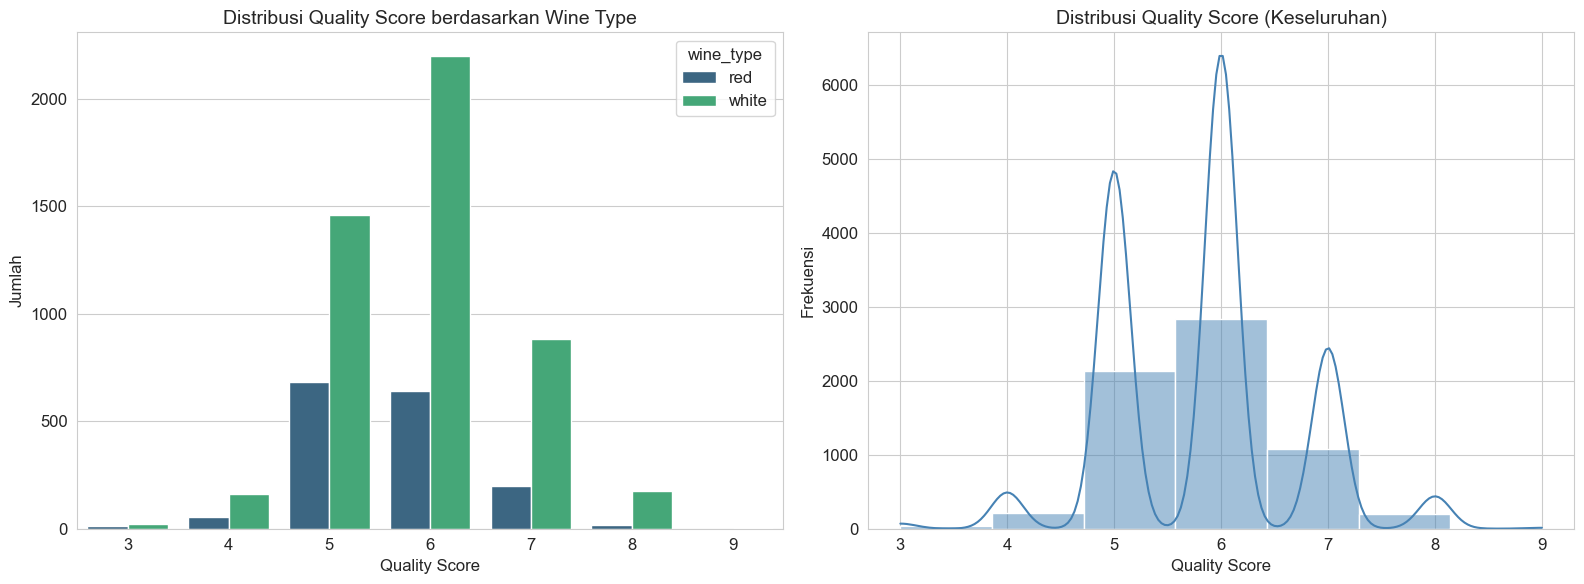


Distribusi Quality Score:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


In [7]:
# 4.3 Distribusi Target Variable (Quality)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribusi quality score
sns.countplot(data=df, x='quality', hue='wine_type', ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Quality Score berdasarkan Wine Type', fontsize=14)
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Jumlah')

# Distribusi keseluruhan
sns.histplot(data=df, x='quality', kde=True, ax=axes[1], color='steelblue', bins=7)
axes[1].set_title('Distribusi Quality Score (Keseluruhan)', fontsize=14)
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print('\nDistribusi Quality Score:')
print(df['quality'].value_counts().sort_index())

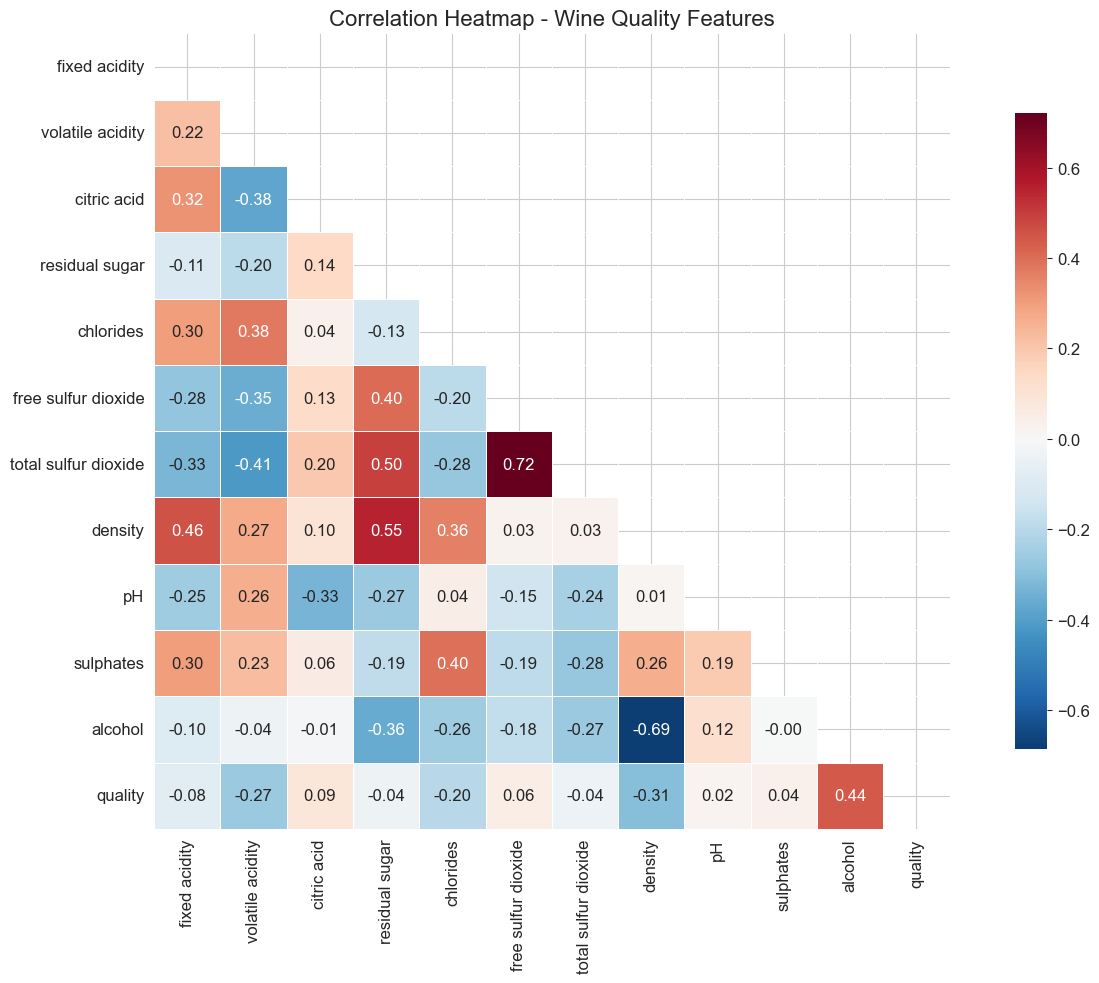


Korelasi fitur dengan Quality (sorted):
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


In [8]:
# 4.4 Correlation Heatmap
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap - Wine Quality Features', fontsize=16)
plt.tight_layout()
plt.show()

# Korelasi dengan target (quality)
print('\nKorelasi fitur dengan Quality (sorted):')
print(corr_matrix['quality'].drop('quality').sort_values(ascending=False))

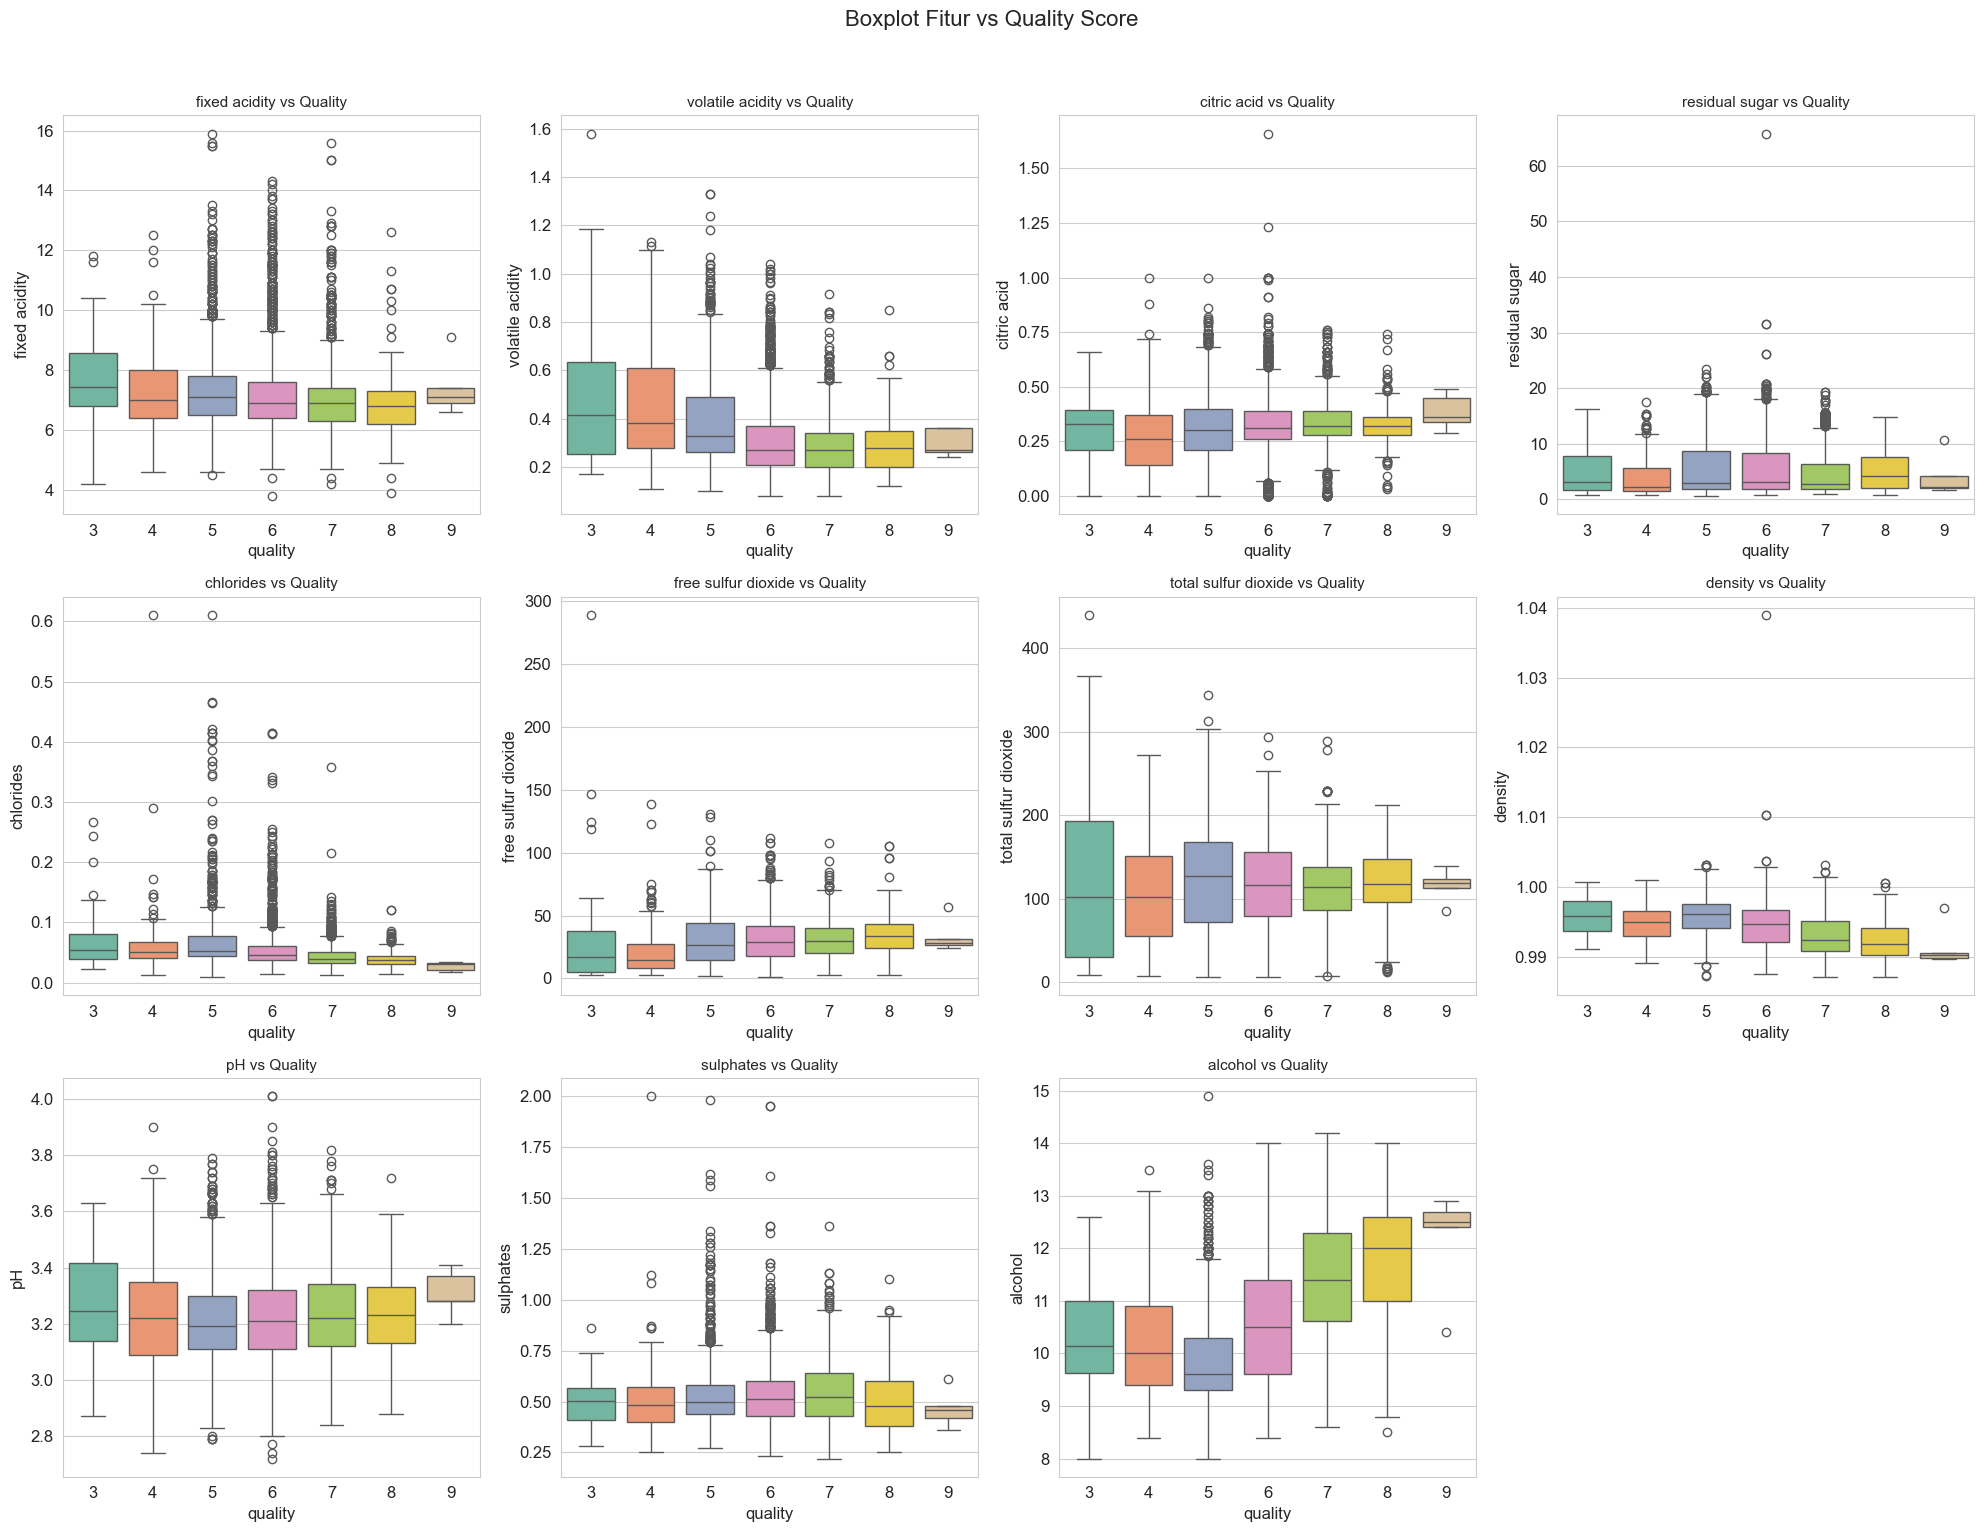

In [9]:
# 4.5 Boxplot untuk Deteksi Outlier
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
numeric_features = df.select_dtypes(include=[np.number]).columns.drop('quality')

for idx, col in enumerate(numeric_features):
    row, col_idx = idx // 4, idx % 4
    sns.boxplot(data=df, y=col, x='quality', ax=axes[row][col_idx], palette='Set2')
    axes[row][col_idx].set_title(f'{col} vs Quality', fontsize=11)
    axes[row][col_idx].tick_params(axis='x', rotation=0)

# Hapus subplot kosong jika ada
for idx in range(len(numeric_features), 12):
    row, col_idx = idx // 4, idx % 4
    fig.delaxes(axes[row][col_idx])

plt.suptitle('Boxplot Fitur vs Quality Score', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

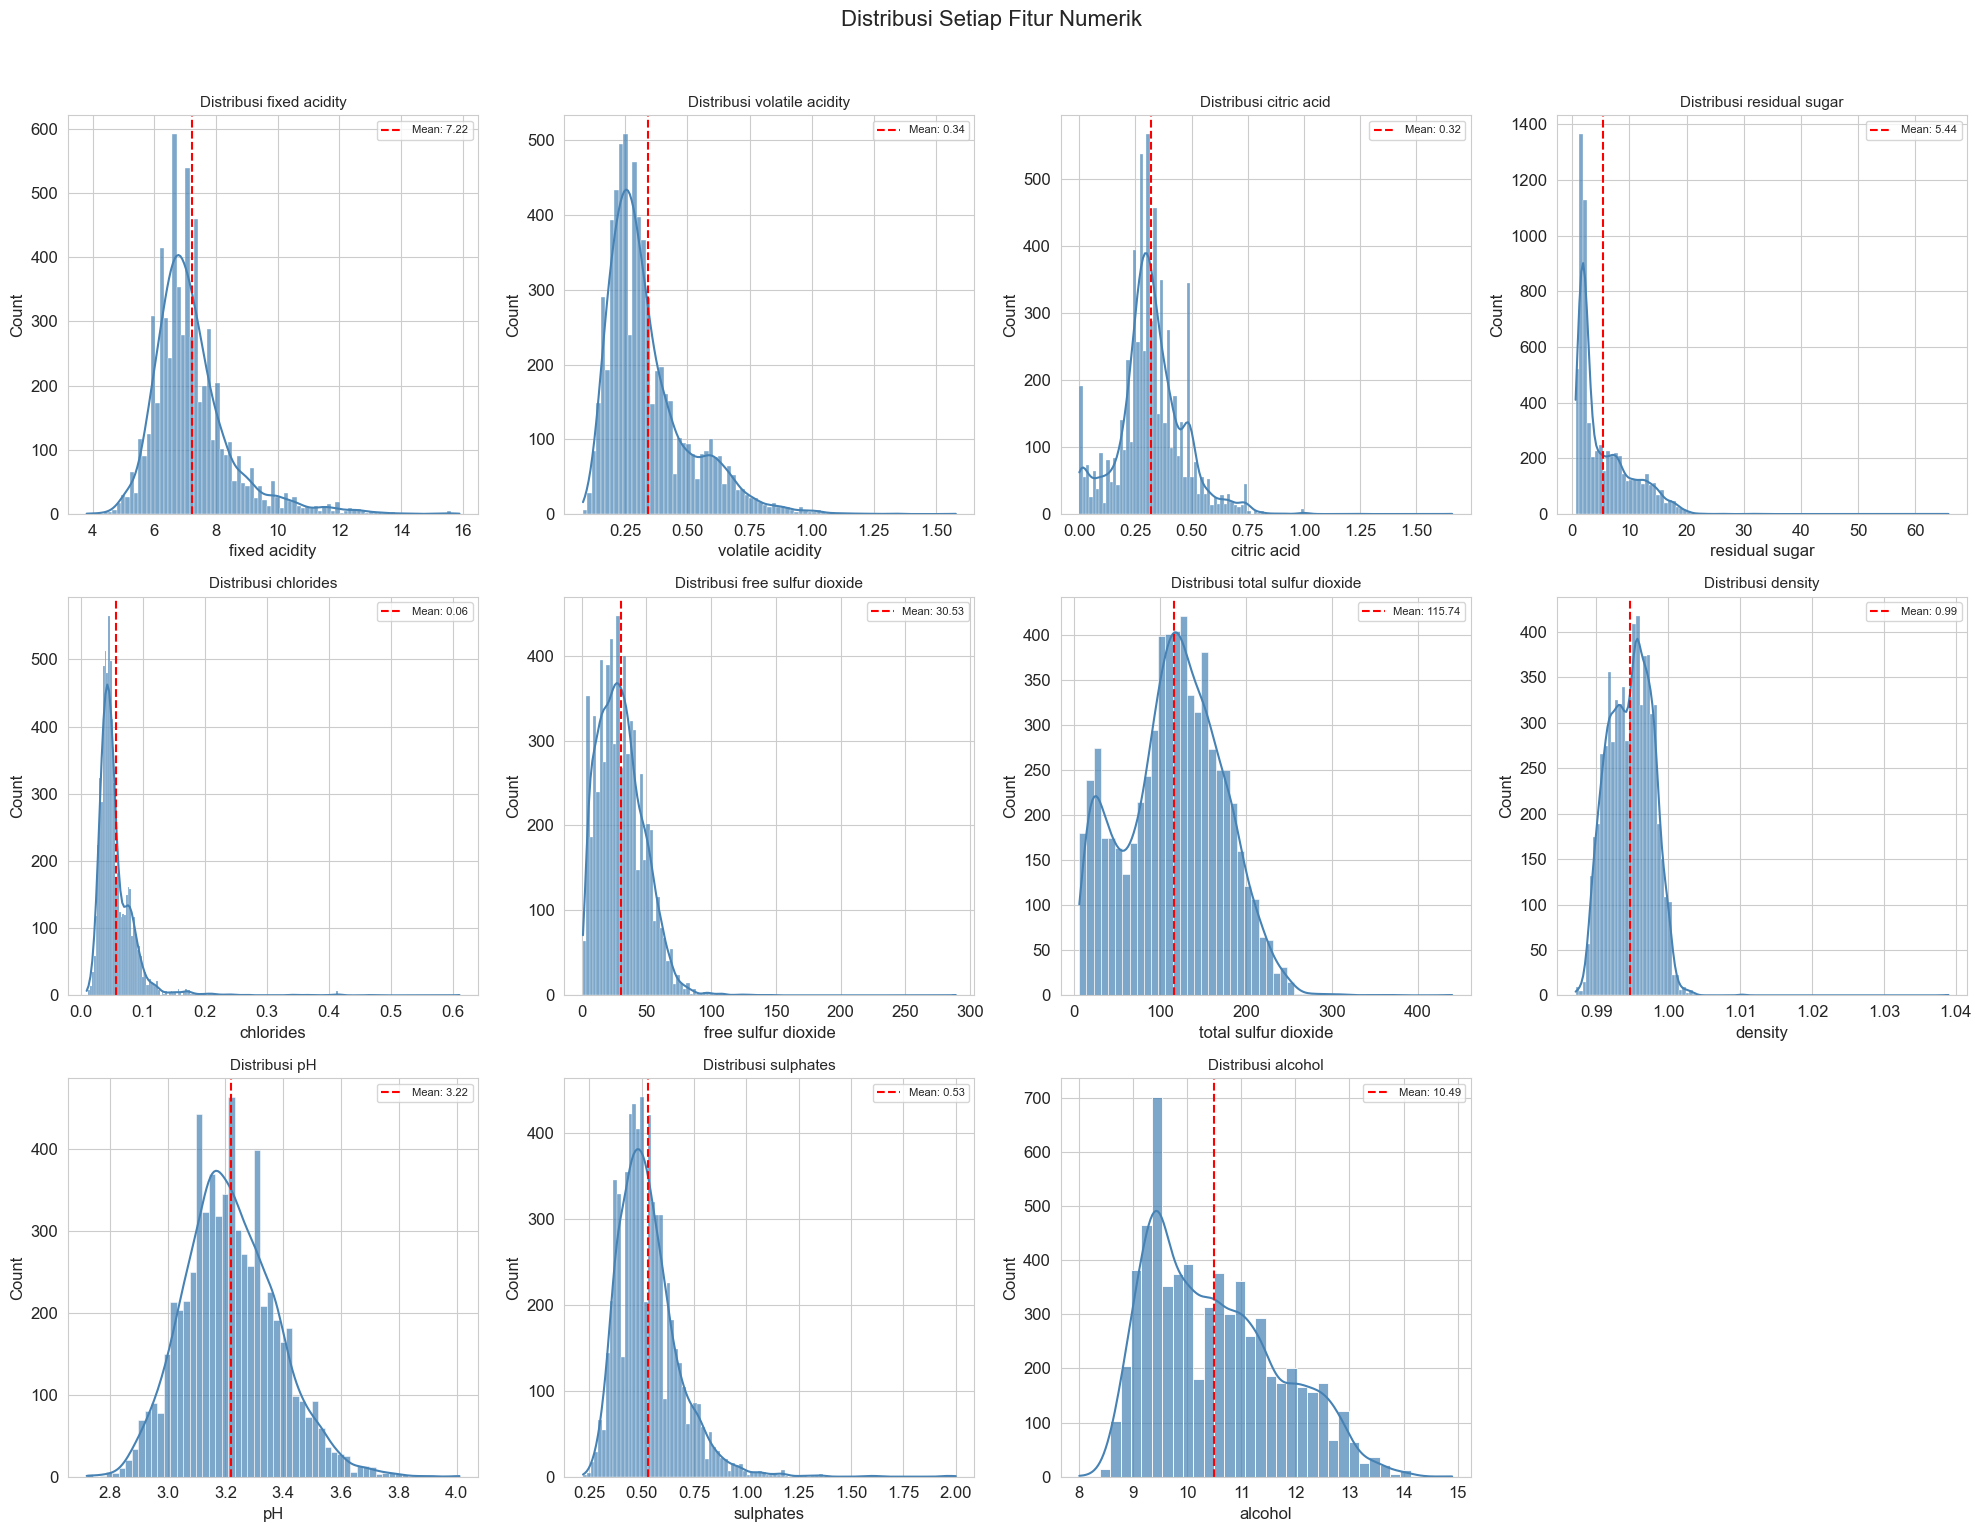

In [10]:
# 4.6 Distribusi setiap fitur
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for idx, col in enumerate(numeric_features):
    row, col_idx = idx // 4, idx % 4
    sns.histplot(data=df, x=col, kde=True, ax=axes[row][col_idx],
                 color='steelblue', alpha=0.7)
    axes[row][col_idx].set_title(f'Distribusi {col}', fontsize=11)
    axes[row][col_idx].axvline(df[col].mean(), color='red',
                                linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[row][col_idx].legend(fontsize=8)

for idx in range(len(numeric_features), 12):
    row, col_idx = idx // 4, idx % 4
    fig.delaxes(axes[row][col_idx])

plt.suptitle('Distribusi Setiap Fitur Numerik', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# 4.7 Analisis Outlier menggunakan IQR Method
print('=== Analisis Outlier (IQR Method) ===')
print(f'{"Fitur":<25} {"Q1":>8} {"Q3":>8} {"IQR":>8} {"Outliers":>10} {"Persen":>8}')
print('-' * 70)

outlier_info = {}
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    persen = outliers / len(df) * 100
    outlier_info[col] = {'lower': lower_bound, 'upper': upper_bound, 'count': outliers}
    print(f'{col:<25} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {outliers:>10} {persen:>7.2f}%')

=== Analisis Outlier (IQR Method) ===
Fitur                           Q1       Q3      IQR   Outliers   Persen
----------------------------------------------------------------------
fixed acidity                 6.40     7.70     1.30        357    5.49%
volatile acidity              0.23     0.40     0.17        377    5.80%
citric acid                   0.25     0.39     0.14        509    7.83%
residual sugar                1.80     8.10     6.30        118    1.82%
chlorides                     0.04     0.07     0.03        286    4.40%
free sulfur dioxide          17.00    41.00    24.00         62    0.95%
total sulfur dioxide         77.00   156.00    79.00         10    0.15%
density                       0.99     1.00     0.00          3    0.05%
pH                            3.11     3.32     0.21         73    1.12%
sulphates                     0.43     0.60     0.17        191    2.94%
alcohol                       9.50    11.30     1.80          3    0.05%


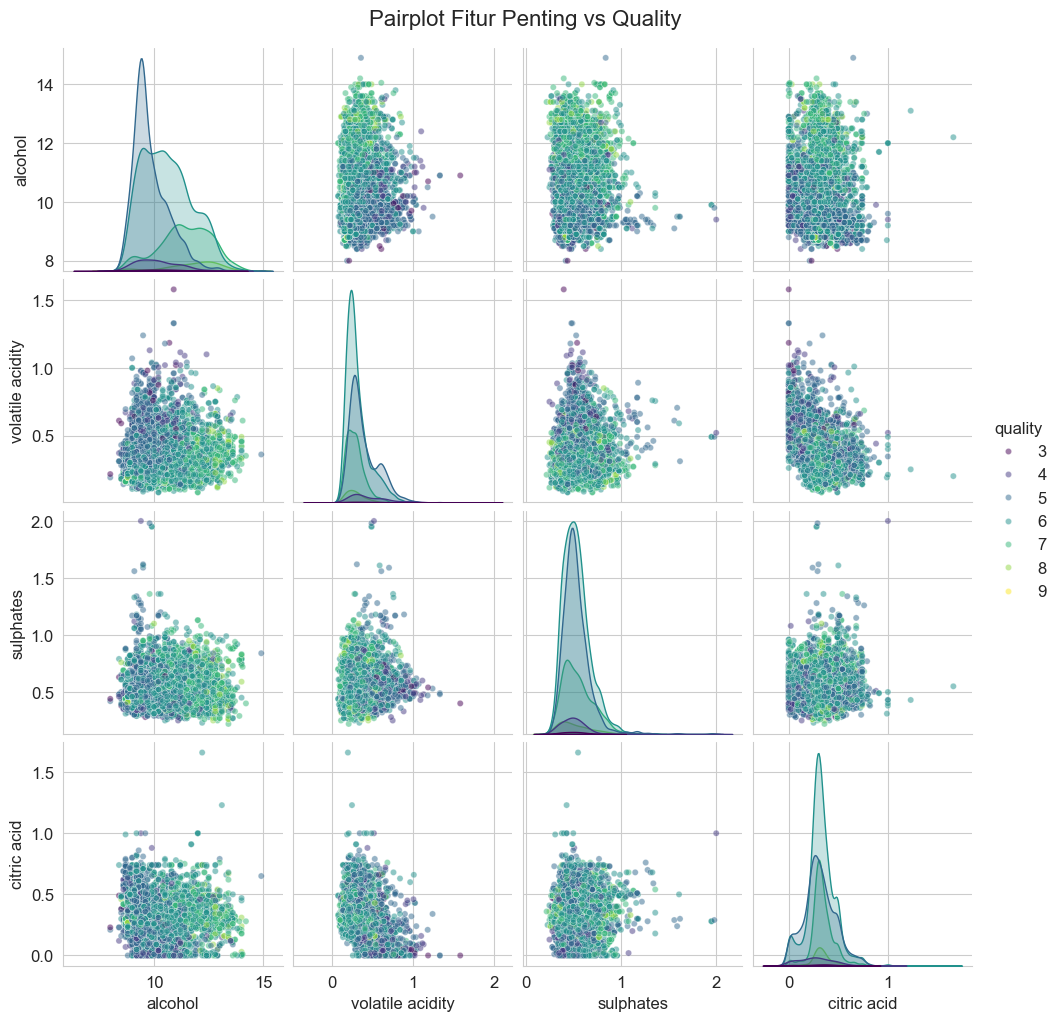

In [12]:
# 4.8 Pairplot fitur penting terhadap quality
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'quality']
sns.pairplot(df[top_features], hue='quality', palette='viridis',
             diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairplot Fitur Penting vs Quality', fontsize=16, y=1.02)
plt.show()

## 5. Data Preprocessing

Pada tahap ini, kita akan melakukan:
1. Menghapus data duplikat
2. Penanganan outlier menggunakan IQR method (capping)
3. Encoding variabel kategorikal (`wine_type`)
4. Konversi target `quality` menjadi binary classification (low=0, high=1)
5. Feature scaling menggunakan StandardScaler
6. Train-test split (80:20)
7. Menyimpan dataset yang sudah dipreprocess

In [13]:
# 5.1 Menghapus Data Duplikat
print(f'Jumlah baris sebelum hapus duplikat: {len(df)}')
df_clean = df.drop_duplicates()
print(f'Jumlah baris setelah hapus duplikat : {len(df_clean)}')
print(f'Baris yang dihapus: {len(df) - len(df_clean)}')

Jumlah baris sebelum hapus duplikat: 6497
Jumlah baris setelah hapus duplikat : 5320
Baris yang dihapus: 1177


In [14]:
# 5.2 Penanganan Outlier menggunakan IQR Capping
print('=== Penanganan Outlier (IQR Capping) ===')
numeric_features_clean = df_clean.select_dtypes(include=[np.number]).columns.drop('quality')

for col in numeric_features_clean:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_before = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    
    # Capping outliers
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
    
    outliers_after = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    
    if outliers_before > 0:
        print(f'{col}: {outliers_before} outliers di-cap')

print('\nOutlier handling selesai!')

=== Penanganan Outlier (IQR Capping) ===
fixed acidity: 304 outliers di-cap
volatile acidity: 279 outliers di-cap
citric acid: 143 outliers di-cap
residual sugar: 141 outliers di-cap
chlorides: 237 outliers di-cap
free sulfur dioxide: 44 outliers di-cap
total sulfur dioxide: 10 outliers di-cap
density: 3 outliers di-cap
pH: 49 outliers di-cap
sulphates: 163 outliers di-cap
alcohol: 1 outliers di-cap

Outlier handling selesai!


In [15]:
# 5.3 Encoding wine_type (Label Encoding: red=0, white=1)
le = LabelEncoder()
df_clean['wine_type'] = le.fit_transform(df_clean['wine_type'])
print('Label Encoding wine_type:')
print(f'  red   -> 0')
print(f'  white -> 1')
print(f'\nDistribusi wine_type setelah encoding:')
print(df_clean['wine_type'].value_counts())

Label Encoding wine_type:
  red   -> 0
  white -> 1

Distribusi wine_type setelah encoding:
wine_type
1    3961
0    1359
Name: count, dtype: int64


Konversi Quality ke Binary Classification:
  Low Quality  (0): quality <= 5
  High Quality (1): quality > 5

Distribusi kelas:
quality_label
1    3332
0    1988
Name: count, dtype: int64

Persentase:
quality_label
1    62.63
0    37.37
Name: proportion, dtype: float64


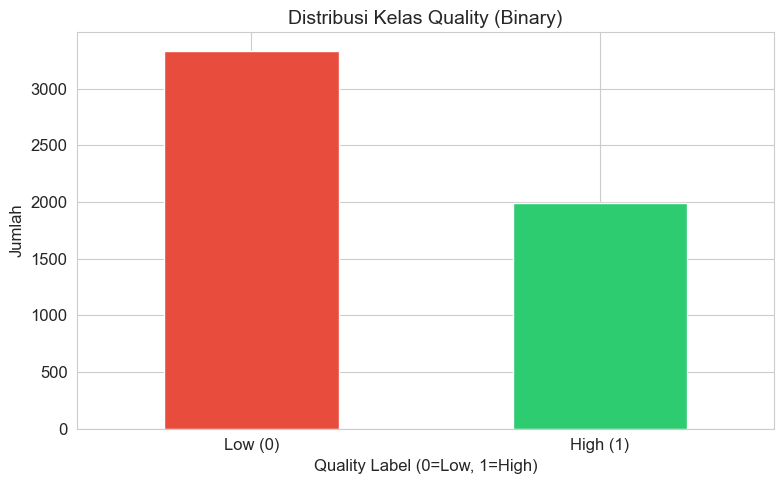

In [16]:
# 5.4 Konversi target quality menjadi binary classification
# quality <= 5 -> 0 (low quality)
# quality > 5  -> 1 (high quality)
df_clean['quality_label'] = (df_clean['quality'] > 5).astype(int)

print('Konversi Quality ke Binary Classification:')
print(f'  Low Quality  (0): quality <= 5')
print(f'  High Quality (1): quality > 5')
print(f'\nDistribusi kelas:')
print(df_clean['quality_label'].value_counts())
print(f'\nPersentase:')
print(df_clean['quality_label'].value_counts(normalize=True).round(4) * 100)

# Visualisasi distribusi kelas
fig, ax = plt.subplots(figsize=(8, 5))
df_clean['quality_label'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], ax=ax)
ax.set_title('Distribusi Kelas Quality (Binary)', fontsize=14)
ax.set_xlabel('Quality Label (0=Low, 1=High)')
ax.set_ylabel('Jumlah')
ax.set_xticklabels(['Low (0)', 'High (1)'], rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# 5.5 Persiapan Features dan Target
X = df_clean.drop(columns=['quality', 'quality_label'])
y = df_clean['quality_label']

print(f'Features shape: {X.shape}')
print(f'Target shape  : {y.shape}')
print(f'\nFitur yang digunakan: {list(X.columns)}')

# 5.6 Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain set: {X_train.shape[0]} sampel')
print(f'Test set : {X_test.shape[0]} sampel')
print(f'\nDistribusi target di train set:')
print(y_train.value_counts())
print(f'\nDistribusi target di test set:')
print(y_test.value_counts())

Features shape: (5320, 12)
Target shape  : (5320,)

Fitur yang digunakan: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'wine_type']

Train set: 4256 sampel
Test set : 1064 sampel

Distribusi target di train set:
quality_label
1    2666
0    1590
Name: count, dtype: int64

Distribusi target di test set:
quality_label
1    666
0    398
Name: count, dtype: int64


In [18]:
# 5.7 Feature Scaling (StandardScaler)
# Fit pada training data, transform pada training dan test data
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('Feature Scaling berhasil diterapkan!')
print(f'\nStatistik X_train setelah scaling:')
print(X_train_scaled.describe().T[['mean', 'std', 'min', 'max']])

Feature Scaling berhasil diterapkan!

Statistik X_train setelah scaling:
                              mean       std       min       max
fixed acidity        -1.085180e-17  1.000118 -2.471722  2.300135
volatile acidity     -1.586033e-16  1.000118 -1.724890  2.263393
citric acid          -3.339017e-17  1.000118 -2.240634  2.303562
residual sugar        1.085180e-16  1.000118 -1.005466  2.592266
chlorides            -6.218918e-17  1.000118 -2.030792  2.464081
free sulfur dioxide  -4.173771e-18  1.000118 -1.702940  2.887519
total sulfur dioxide  2.838164e-17  1.000118 -1.904861  2.803630
density              -1.527600e-14  1.000118 -2.569535  3.129792
pH                    7.312446e-16  1.000118 -2.800957  2.733135
sulphates            -1.020070e-15  1.000118 -2.132533  2.498325
alcohol               1.298877e-15  1.000118 -2.137808  3.111596
wine_type            -1.523426e-16  1.000118 -1.687632  0.592546


In [19]:
# 5.8 Simpan Dataset yang Sudah Dipreprocess
import os

output_dir = 'winequality_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# Gabungkan X dan y kembali untuk disimpan
train_data = X_train_scaled.copy()
train_data['quality_label'] = y_train.values

test_data = X_test_scaled.copy()
test_data['quality_label'] = y_test.values

# Simpan
train_data.to_csv(os.path.join(output_dir, 'train_data.csv'), index=False)
test_data.to_csv(os.path.join(output_dir, 'test_data.csv'), index=False)

# Simpan juga dataset lengkap yang sudah dipreprocess (sebelum split)
df_preprocessed = df_clean.copy()
df_preprocessed.to_csv(os.path.join(output_dir, 'winequality_preprocessed.csv'), index=False)

print('Dataset berhasil disimpan!')
print(f'  - {output_dir}/train_data.csv ({len(train_data)} baris)')
print(f'  - {output_dir}/test_data.csv ({len(test_data)} baris)')
print(f'  - {output_dir}/winequality_preprocessed.csv ({len(df_preprocessed)} baris)')

Dataset berhasil disimpan!
  - winequality_preprocessing/train_data.csv (4256 baris)
  - winequality_preprocessing/test_data.csv (1064 baris)
  - winequality_preprocessing/winequality_preprocessed.csv (5320 baris)


## Kesimpulan

Dari proses EDA dan preprocessing yang dilakukan, berikut rangkuman:

1. **Dataset**: Wine Quality Dataset berisi 6.497 sampel (1.599 red + 4.898 white) dengan 11 fitur numerik
2. **Missing Values**: Tidak ditemukan missing values
3. **Duplikat**: Beberapa baris duplikat ditemukan dan dihapus
4. **Outlier**: Ditemukan outlier pada beberapa fitur, ditangani dengan IQR capping
5. **Target**: Quality score (3-9) dikonversi ke binary classification (low=0, high=1)
6. **Scaling**: StandardScaler diterapkan pada fitur numerik (fit di train, transform di train+test)
7. **Split**: 80% training, 20% testing dengan stratified sampling

Dataset siap digunakan untuk pelatihan model machine learning!